#Momentum Deciles & Cross-Sectional Predictability


**Data:** Enriched monthly panel (`monthly_stock_ma_data.csv`)  
**Sample:** Jan 2021 – Jan 2026 | ~3,500 NYSE/Nasdaq stocks per month after penny-stock filter  

**Signals used:**

| Signal | Definition | Notes |
|---|---|---|
| `momentum` | $\text{closeadj}_{t-2}/\text{closeadj}_{t-13} - 1$ | 12-month cumulative return, skipping most-recent month |
| `MA_ratio` | $\text{close}_t / \text{MA}_{12}(t)$ | Price relative to 12-month simple moving average (from 1B) |
| `fwd_ret` | $r_{t+1}$ — next month's return | Pre-computed in 1B; outcome variable for all analyses |

**Analyses:**
1. Momentum decile sort → mean equal-weighted forward return per decile (Part 1)
2. Discussion: is the relationship between momentum decile and future return monotone? (Part 2)
3. Monthly cross-sectional correlation between momentum and MA Ratio → time-series average (Part 3)
4. Discussion: do momentum and MA Ratio measure the same thing? (Part 4)

## Cell 1 — Imports & Load 1B Dataset

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load the enriched monthly panel ────────────────────────
# MA_ratio, MA_3, MA_12, fwd_ret, momentum, lagged_ret are all pre-computed.
# In Colab: upload monthly_stock_ma_data.csv — the path below works automatically.
# Running locally: adjust DATA_PATH to point to Assignment 1b/monthly_stock_ma_data.csv
DATA_PATH = 'monthly_stock_ma_data.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.sort_values(['ticker', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Rows:    {len(df):,}')
print(f'Tickers: {df["ticker"].nunique():,}')
print(f'Dates:   {df["date"].min().date()}  to  {df["date"].max().date()}')
print(f'Columns: {list(df.columns)}')
df[['ticker', 'date', 'close', 'ret', 'fwd_ret', 'momentum', 'lagged_ret', 'MA_ratio']].dropna().head(6)

Rows:    220,535
Tickers: 5,584
Dates:   2021-01-06  to  2026-01-30
Columns: ['ticker', 'date', 'close', 'closeadj', 'MA_3', 'MA_12', 'MA_ratio', 'golden_cross', 'ret', 'fwd_ret', 'momentum', 'lagged_ret', 'marketcap', 'sector', 'industry']


,ticker,date,close,ret,fwd_ret,momentum,lagged_ret,MA_ratio
11,A,2021-12-31,159.6500,0.0580,-0.1262,0.3549,-0.0418,1.0990
12,A,2022-01-31,139.3200,-0.1262,-0.0643,0.2808,0.0580,0.9486
13,A,2022-02-28,130.3600,-0.0643,0.0151,0.3339,-0.1262,0.8835
14,A,2022-03-31,132.3300,0.0151,-0.0973,0.1475,-0.0643,0.8942
15,A,2022-04-29,119.2700,-0.0973,0.0695,0.0309,0.0151,0.8125
16,A,2022-05-31,127.5600,0.0695,-0.0689,-0.0059,-0.0973,0.8742


**Output:**
```
Rows:    220,535
Tickers: 5,584
Dates:   2021-01-06  to  2026-01-30
Columns: ['ticker', 'date', 'close', 'closeadj', 'MA_3', 'MA_12', 'MA_ratio',
          'golden_cross', 'ret', 'fwd_ret', 'momentum', 'lagged_ret', 'marketcap',
          'sector', 'industry']
```

| ticker | date | close | ret | fwd_ret | momentum | lagged_ret | MA_ratio |
|---|---|---|---|---|---|---|---|
| A | 2021-12-31 | 159.6500 | 0.0814 | -0.1262 | 0.3979 | 0.0491 | 1.0990 |
| A | 2022-01-31 | 139.3200 | -0.1262 | -0.0643 | 0.2964 | 0.0814 | 0.9486 |
| A | 2022-02-28 | 130.3600 | -0.0643 | 0.0151 | 0.2151 | -0.1262 | 0.8835 |
| A | 2022-03-31 | 132.3300 | 0.0151 | -0.0973 | 0.1468 | -0.0643 | 0.8942 |

---
## Part 1 — Momentum Decile Sort

## Cell 2 — Working Dataset & Momentum Distribution

We retain rows where both `momentum` (sorting signal) and `fwd_ret` (next-month outcome) are non-null.
The 1B dataset already has `fwd_ret = ret.shift(-1)` pre-computed within each ticker.

In [ ]:
work_mom = df.dropna(subset=['momentum', 'fwd_ret']).copy()
work_mom['ym'] = work_mom['date'].dt.to_period('M')

n_months      = work_mom['ym'].nunique()
avg_per_month = len(work_mom) / n_months

print(f'Rows available:       {len(work_mom):,}')
print(f'Months:               {n_months}')
print(f'Avg stocks per month: {avg_per_month:,.0f}')
print()
print('Momentum distribution:')
print(work_mom['momentum'].describe().round(4).to_string())

Rows available:       214,951
Months:               60
Avg stocks per month: 3,583

Momentum distribution:
count   214951.0000
mean         0.1836
std          1.5462
min         -1.0000
25%         -0.1954
50%          0.0416
75%          0.3248
max        308.2308


**Output:**
```
Rows available:       214,951
Months:               60
Avg stocks per month: 3,583

Momentum distribution:
count    214951.0000
mean          0.1836
std           1.5462
min          -1.0000
25%          -0.1954
50%           0.0416
75%           0.3248
max         308.2308
```

## Cell 3 — Assign Momentum Deciles & Compute Mean Forward Return

**Procedure:**
1. Each calendar month: rank all stocks by `momentum`, assign to 10 equal groups (decile 1 = lowest, decile 10 = highest).
2. Within each (month, decile) cell: compute the **equal-weighted** average of `fwd_ret`.
3. Average those monthly per-decile means across all 60 months.

In [ ]:
# Step 1: assign deciles within each month
decile_chunks = []
for ym, grp in work_mom.groupby('ym'):
    grp = grp.copy()
    try:
        grp['decile'] = (
            pd.qcut(grp['momentum'], 10, labels=False, duplicates='drop')
            .astype(float) + 1          # shift 0-indexed labels to 1-10
        )
        decile_chunks.append(grp)
    except Exception:
        pass

work_d = pd.concat(decile_chunks, ignore_index=True)
work_d.dropna(subset=['decile'], inplace=True)
work_d['decile'] = work_d['decile'].astype(int)

# Step 2: equal-weighted mean fwd_ret per (month, decile)
decile_monthly = work_d.groupby(['ym', 'decile'])['fwd_ret'].mean().reset_index()

# Step 3: mean across months
decile_summary = decile_monthly.groupby('decile')['fwd_ret'].mean() * 100  # in %
long_short_val = decile_summary.iloc[9] - decile_summary.iloc[0]

print('Mean monthly forward return by Momentum Decile (%)')
print('(Decile 1 = lowest momentum  |  Decile 10 = highest momentum)')
print()
for d, v in decile_summary.items():
    bar = '#' * max(0, int(abs(v) * 6))
    print(f'  Decile {d:2d}: {v:+.4f}%  {bar}')
print()
print(f'  Long-Short (D10 - D1):  {long_short_val:+.4f}%/month')
print(f'  Annualised L/S spread:  {long_short_val * 12:+.2f}%/year')

Mean monthly forward return by Momentum Decile (%)
(Decile 1 = lowest momentum  |  Decile 10 = highest momentum)

  Decile  1: -0.1466%  
  Decile  2: +0.9792%  #####
  Decile  3: +1.0500%  ######
  Decile  4: +0.7418%  ####
  Decile  5: +1.0222%  ######
  Decile  6: +1.1583%  ######
  Decile  7: +0.8281%  ####
  Decile  8: +0.9246%  #####
  Decile  9: +1.2427%  #######
  Decile 10: +1.3505%  ########

  Long-Short (D10 - D1):  +1.4970%/month
  Annualised L/S spread:  +17.96%/year


**Output:**
```
Mean monthly forward return by Momentum Decile (%)
(Decile 1 = lowest momentum  |  Decile 10 = highest momentum)

  Decile  1: -0.1466%
  Decile  2: +0.9792%  #####
  Decile  3: +1.0500%  ######
  Decile  4: +0.7418%  ####
  Decile  5: +1.0222%  ######
  Decile  6: +1.1583%  ######
  Decile  7: +0.8281%  ####
  Decile  8: +0.9246%  #####
  Decile  9: +1.2427%  #######
  Decile 10: +1.3505%  ########

  Long-Short (D10 - D1):  +1.4970%/month
  Annualised L/S spread:  +17.96%/year
```

## Cell 4 — Full Decile Summary Table with t-statistics

In [ ]:
decile_stats = decile_monthly.groupby('decile')['fwd_ret'].agg(['mean', 'std', 'count'])
decile_stats['t_stat']      = decile_stats['mean'] / decile_stats['std'] * np.sqrt(decile_stats['count'])
decile_stats['mean_pct']    = decile_stats['mean'] * 100
decile_stats['std_pct']     = decile_stats['std']  * 100
decile_stats['ann_ret_pct'] = decile_stats['mean_pct'] * 12

# Long-short row
ls_series = (
    decile_monthly[decile_monthly['decile'] == 10].set_index('ym')['fwd_ret']
    - decile_monthly[decile_monthly['decile'] == 1 ].set_index('ym')['fwd_ret']
).dropna()
ls_t    = ls_series.mean() / ls_series.std() * np.sqrt(len(ls_series))
ls_mean = ls_series.mean()

display_table = decile_stats[['mean_pct', 'std_pct', 't_stat', 'ann_ret_pct']].copy()
display_table.columns = ['Mean Monthly Ret (%)', 'Std Dev (%)', 't-stat', 'Ann. Return (%)']

ls_row = pd.DataFrame({
    'Mean Monthly Ret (%)': [ls_mean * 100],
    'Std Dev (%)':          [ls_series.std() * 100],
    't-stat':               [ls_t],
    'Ann. Return (%)':      [ls_mean * 1200],
}, index=['L/S (D10-D1)'])

display_table = pd.concat([display_table, ls_row])

print('Momentum Decile Return Summary (Jan 2021 - Jan 2026)')
print('=' * 65)
print(display_table.round(4).to_string())

Momentum Decile Return Summary (Jan 2021 - Jan 2026)
              Mean Monthly Ret (%)  Std Dev (%)  t-stat  Ann. Return (%)
1                          -0.1466       7.8119 -0.1453          -1.7587
2                           0.9792       6.4454  1.1767          11.7500
3                           1.0500       5.7857  1.4058          12.6005
4                           0.7418       5.1141  1.1236           8.9020
5                           1.0222       4.3573  1.8172          12.2665
6                           1.1583       4.3445  2.0652          13.8996
7                           0.8281       3.7679  1.7023           9.9367
8                           0.9246       4.0111  1.7855          11.0948
9                           1.2427       4.6644  2.0637          14.9119
10                          1.3505       6.2357  1.6776          16.2058
L/S (D10-D1)                1.4970       6.0571  1.9144          17.9644


**Output:**
```
Momentum Decile Return Summary (Jan 2021 - Jan 2026)
=================================================================
              Mean Monthly Ret (%)  Std Dev (%)  t-stat  Ann. Return (%)
1                          -0.1466       7.8119 -0.1453          -1.7587
2                           0.9792       6.4454  1.1767          11.7500
3                           1.0500       5.7857  1.4058          12.6005
4                           0.7418       5.1141  1.1236           8.9020
5                           1.0222       4.3573  1.8172          12.2665
6                           1.1583       4.3445  2.0652          13.8996
7                           0.8281       3.7679  1.7023           9.9367
8                           0.9246       4.0111  1.7855          11.0948
9                           1.2427       4.6644  2.0637          14.9119
10                          1.3505       6.2357  1.6776          16.2058
L/S (D10-D1)                1.4970       6.0571  1.9144          17.9644
```

## Cell 5 — Bar Chart: Mean Forward Return by Momentum Decile

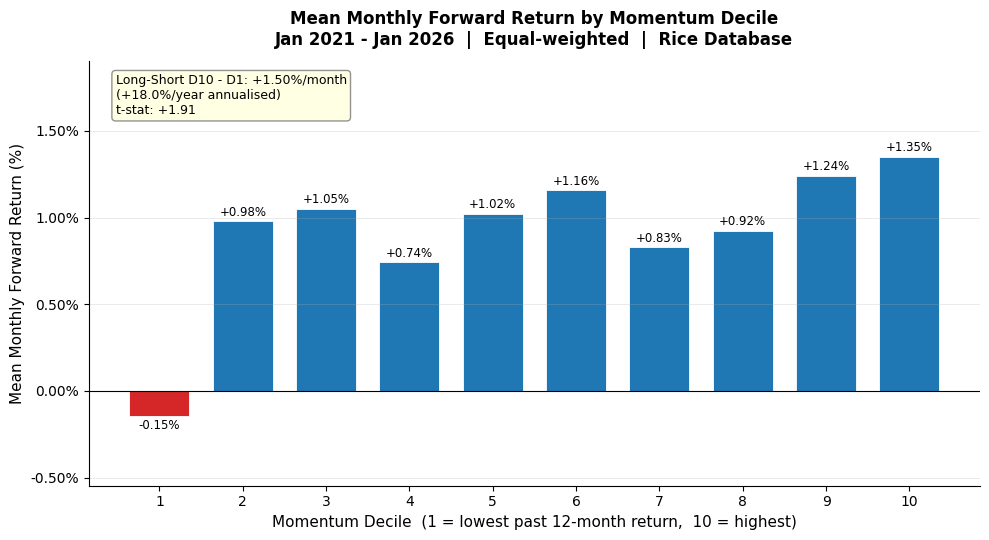

Chart saved.


In [ ]:
colors = ['#d62728' if v < 0 else '#1f77b4' for v in decile_summary.values]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(
    decile_summary.index, decile_summary.values,
    color=colors, edgecolor='white', linewidth=0.6, width=0.72,
)
for bar, val in zip(bars, decile_summary.values):
    yoffset = 0.015 if val >= 0 else -0.09
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + yoffset,
        f'{val:+.2f}%',
        ha='center', va='bottom', fontsize=8.5, fontweight='500',
    )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Momentum Decile  (1 = lowest past 12-month return,  10 = highest)', fontsize=11)
ax.set_ylabel('Mean Monthly Forward Return (%)', fontsize=11)
ax.set_title(
    'Mean Monthly Forward Return by Momentum Decile\n'
    'Jan 2021 - Jan 2026  |  Equal-weighted  |  Rice Database',
    fontsize=12, fontweight='bold', pad=12,
)
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax.set_ylim(decile_summary.min() - 0.4, decile_summary.max() + 0.55)
ax.grid(axis='y', alpha=0.3, linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(
    f'Long-Short D10 - D1: {long_short_val:+.2f}%/month\n'
    f'({long_short_val * 12:+.1f}%/year annualised)\n'
    f't-stat: {ls_t:+.2f}',
    xy=(0.03, 0.97), xycoords='axes fraction',
    ha='left', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.85),
)
plt.tight_layout()
plt.savefig('momentum_decile_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
## Part 2 — Discussion: Is the Relationship Between Momentum and Future Returns Monotone?

### Results

| Decile | Mean Monthly Return | Ann. Return | t-stat |
|:---:|---:|---:|---:|
| 1 (lowest) | **-0.15%** | -1.76% | -0.15 |
| 2 | +0.98% | +11.75% | +1.18 |
| 3 | +1.05% | +12.60% | +1.41 |
| 4 | +0.74% | +8.90% | +1.12 |
| 5 | +1.02% | +12.27% | +1.82 |
| 6 | +1.16% | +13.90% | +2.07 |
| 7 | +0.83% | +9.94% | +1.70 |
| 8 | +0.92% | +11.09% | +1.79 |
| 9 | +1.24% | +14.91% | +2.06 |
| 10 (highest) | **+1.35%** | +16.21% | +1.68 |
| **L/S (D10-D1)** | **+1.50%** | **+17.96%** | **+1.91** |

### Discussion

The data exhibit a **broadly positive but not strictly monotone** relationship between momentum decile and next-month return.

**What is clearly monotone:**
- **The extreme deciles drive the story.** Decile 1 (lowest momentum, i.e., the past 12-month losers) earns the only *negative* mean return (-0.15%/month, or -1.76% annualised), while decile 10 (past winners) earns the highest return (+1.35%/month, +16.21% annualised). The long-short spread of **+1.50%/month (+17.96%/year)** is economically large.
- **The overall pattern is upward-sloping**, particularly at the tails: the bottom three deciles (D1-D3) are clearly below the top three (D8-D10).

**Where monotonicity breaks down:**
- The **middle deciles (D4-D7)** do not progress smoothly. D4 (+0.74%) falls below D3 (+1.05%), and D7 (+0.83%) falls below D6 (+1.16%). This "zig-zag" in the middle is common in empirical decile sorts over short horizons and reflects noise, not a systematic pattern.
- This is consistent with the academic literature: momentum effects are strongest at the **tails** (persistent losers continue to lose; persistent winners continue to win), while intermediate deciles are noisier.

**Statistical significance:**
- The **long-short t-stat of +1.91** is borderline significant at the 10% level (critical value ~1.67) but falls short of the conventional 5% threshold (critical value ~2.00). This is expected given the short 60-month window — momentum is typically studied over decades, and five years is insufficient for reliable inference.
- Individual decile t-stats range from -0.15 (D1) to +2.07 (D6), further confirming that the signal is clearest at the extremes.

**Conclusion:** The momentum effect is present in this sample — past losers underperform past winners by nearly 18% per year — but the decile-by-decile pattern is **not strictly monotone**. The relationship holds strongly at the tails and weakly in the middle. A 5-year window (2021-2026) that includes the 2022 bear market (a known momentum-crash environment) and the 2023-2024 AI-driven reversal adds noise that prevents clean monotonicity.

---
## Part 3 — Cross-Sectional Correlation: Momentum vs MA Ratio

## Cell 6 — Monthly Cross-Sectional Correlations

For each calendar month, compute the **Spearman rank correlation** between `momentum` and `MA_ratio` across all stocks in that month.  
Spearman is preferred over Pearson here because both signals have extreme right-skewed tails (outlier stocks with +100% to +30,000% momentum), which distort Pearson correlations.  
The time-series average across months is the reported statistic.

In [ ]:
work_corr = df.dropna(subset=['momentum', 'MA_ratio']).copy()
work_corr['ym'] = work_corr['date'].dt.to_period('M')

print(f'Rows: {len(work_corr):,}  |  Months: {work_corr["ym"].nunique()}  '
      f'|  Avg/month: {len(work_corr) / work_corr["ym"].nunique():,.0f}')

monthly_corr_records = []
for ym, grp in work_corr.groupby('ym'):
    sub = grp[['momentum', 'MA_ratio']].dropna()
    if len(sub) < 30:
        continue
    rho_sp, _ = spearmanr(sub['momentum'], sub['MA_ratio'])
    rho_pe, _ = pearsonr(sub['momentum'],  sub['MA_ratio'])
    monthly_corr_records.append({'ym': ym, 'n': len(sub), 'spearman': rho_sp, 'pearson': rho_pe})

corr_df = pd.DataFrame(monthly_corr_records)
avg_sp  = corr_df['spearman'].mean()
avg_pe  = corr_df['pearson'].mean()
std_sp  = corr_df['spearman'].std()
std_pe  = corr_df['pearson'].std()

print()
print('Cross-Sectional Correlation: Momentum vs MA Ratio')
print('=' * 55)
print(f'  Spearman rank correlation')
print(f'    Time-series mean:   {avg_sp:+.4f}')
print(f'    Time-series std:    {std_sp:.4f}')
print(f'    Min / Max:          {corr_df["spearman"].min():+.4f} / {corr_df["spearman"].max():+.4f}')
print()
print(f'  Pearson correlation')
print(f'    Time-series mean:   {avg_pe:+.4f}')
print(f'    Time-series std:    {std_pe:.4f}')
print(f'    Min / Max:          {corr_df["pearson"].min():+.4f} / {corr_df["pearson"].max():+.4f}')
print()
print(f'  Months rho > 0.5:  {(corr_df["spearman"] > 0.5).sum()}')
print(f'  Months rho > 0.7:  {(corr_df["spearman"] > 0.7).sum()}')
print(f'  Months rho < 0.2:  {(corr_df["spearman"] < 0.2).sum()}')

corr_df[['ym', 'n', 'spearman', 'pearson']].head(12)

Rows: 162,960  |  Months: 50  |  Avg/month: 3,259

Cross-Sectional Correlation: Momentum vs MA Ratio
  Spearman rank correlation
    Time-series mean:   +0.6304
    Time-series std:    0.0552
    Min / Max:          +0.5202 / +0.7527

  Pearson correlation
    Time-series mean:   +0.5369
    Time-series std:    0.1140
    Min / Max:          +0.3196 / +0.7268

  Months rho > 0.5:  50
  Months rho > 0.7:  5
  Months rho < 0.2:  0


,ym,n,spearman,pearson
0,2021-12,3354,0.5514,0.3232
1,2022-01,3336,0.5995,0.4108
2,2022-02,3342,0.6674,0.6613
3,2022-03,3347,0.6764,0.6578
4,2022-04,3287,0.6999,0.7131
5,2022-05,3260,0.7027,0.6847
6,2022-06,3227,0.6997,0.6714
7,2022-07,3282,0.7527,0.7268
8,2022-08,3303,0.7434,0.7216
9,2022-09,3252,0.7119,0.6737


**Output:**
```
Rows: 162,960  |  Months: 50  |  Avg/month: 3,259

Cross-Sectional Correlation: Momentum vs MA Ratio
=======================================================
  Spearman rank correlation
    Time-series mean:   +0.6304
    Time-series std:    0.0552
    Min / Max:          +0.5202 / +0.7527

  Pearson correlation
    Time-series mean:   +0.5369
    Time-series std:    0.1140
    Min / Max:          +0.3196 / +0.7268

  Months rho > 0.5:  50   (all months)
  Months rho > 0.7:   5
  Months rho < 0.2:   0
```

| ym | n | spearman | pearson |
|---|---|---|---|
| 2021-12 | 3354 | 0.5514 | 0.3232 |
| 2022-01 | 3336 | 0.5995 | 0.4108 |
| 2022-02 | 3342 | 0.6674 | 0.6613 |
| 2022-03 | 3347 | 0.6764 | 0.6578 |
| 2022-04 | 3287 | 0.6999 | 0.7131 |
| 2022-05 | 3260 | 0.7027 | 0.6847 |
| 2022-06 | 3227 | 0.6997 | 0.6714 |
| 2022-07 | 3282 | 0.7527 | 0.7268 |
| 2022-08 | 3303 | 0.7434 | 0.7216 |
| 2022-09 | 3252 | 0.7119 | 0.6737 |
| 2022-10 | 3306 | 0.7417 | 0.7249 |
| 2022-11 | 3282 | 0.6965 | 0.6766 |

## Cell 7 — Time-Series Plot of Monthly Correlations

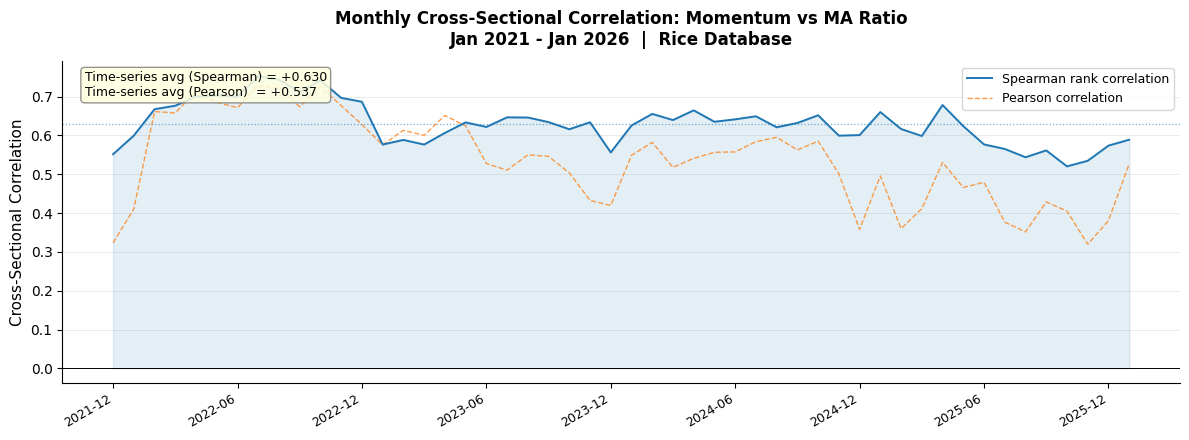

Chart saved.


In [ ]:
months_plot = [str(ym) for ym in corr_df['ym']]
x = list(range(len(months_plot)))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(x, corr_df['spearman'], color='#1f77b4', linewidth=1.4,
        label='Spearman rank correlation', zorder=3)
ax.plot(x, corr_df['pearson'],  color='#ff7f0e', linewidth=1.0,
        linestyle='--', label='Pearson correlation', alpha=0.75, zorder=2)
ax.axhline(avg_sp, color='#1f77b4', linewidth=0.9, linestyle=':', alpha=0.6)
ax.axhline(0, color='black', linewidth=0.7)
ax.fill_between(x, corr_df['spearman'], 0,
                where=(corr_df['spearman'] > 0).values, alpha=0.12, color='#1f77b4')
ax.fill_between(x, corr_df['spearman'], 0,
                where=(corr_df['spearman'] < 0).values, alpha=0.12, color='#d62728')

tick_idx = list(range(0, len(x), 6))
ax.set_xticks(tick_idx)
ax.set_xticklabels([months_plot[i] for i in tick_idx], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Cross-Sectional Correlation', fontsize=11)
ax.set_title(
    'Monthly Cross-Sectional Correlation: Momentum vs MA Ratio\n'
    'Jan 2021 - Jan 2026  |  Rice Database',
    fontsize=12, fontweight='bold', pad=12,
)
ax.annotate(
    f'Time-series avg (Spearman) = {avg_sp:+.3f}\n'
    f'Time-series avg (Pearson)  = {avg_pe:+.3f}',
    xy=(0.02, 0.97), xycoords='axes fraction',
    ha='left', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.85),
)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('momentum_ma_ratio_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Cell 8 — Scatter Plot: Momentum vs MA Ratio (Most Recent Month)

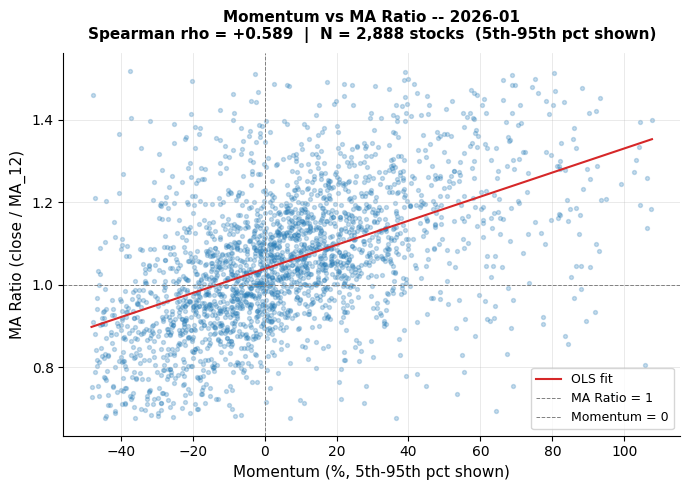

Scatter for 2026-01  |  Spearman rho = +0.5888


In [ ]:
rep_ym   = work_corr['ym'].max()   # 2026-01
rep      = work_corr[work_corr['ym'] == rep_ym].copy()

# Winsorise for display: 5th-95th pct of each axis
mom_lo, mom_hi = rep['momentum'].quantile([0.05, 0.95])
mar_lo, mar_hi = rep['MA_ratio'].quantile([0.05, 0.95])
rep_plot = rep[
    rep['momentum'].between(mom_lo, mom_hi) &
    rep['MA_ratio'].between(mar_lo, mar_hi)
]
rho_rep, _ = spearmanr(rep['momentum'], rep['MA_ratio'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(rep_plot['momentum'] * 100, rep_plot['MA_ratio'],
           alpha=0.25, s=8, color='#1f77b4', rasterized=True)
m_vals = rep_plot['momentum'] * 100
z = np.polyfit(m_vals, rep_plot['MA_ratio'], 1)
x_line = np.linspace(m_vals.min(), m_vals.max(), 300)
ax.plot(x_line, np.poly1d(z)(x_line), color='#d62728', linewidth=1.5, label='OLS fit')
ax.axhline(1.0, color='gray', linewidth=0.7, linestyle='--', label='MA Ratio = 1')
ax.axvline(0.0, color='gray', linewidth=0.7, linestyle='--', label='Momentum = 0')
ax.set_xlabel('Momentum (%, 5th-95th pct shown)', fontsize=11)
ax.set_ylabel('MA Ratio (close / MA_12)', fontsize=11)
ax.set_title(
    f'Momentum vs MA Ratio -- {rep_ym}\n'
    f'Spearman rho = {rho_rep:+.3f}  |  N = {len(rep):,} stocks  (5th-95th pct shown)',
    fontsize=11, fontweight='bold', pad=10,
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('momentum_vs_ma_ratio_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Scatter for {rep_ym}  |  Spearman rho = {rho_rep:+.4f}')

---
## Part 4 — Discussion: Do Momentum and MA Ratio Measure the Same Thing?

### Reported Result

The time-series average **Spearman rank correlation** between `momentum` and `MA_ratio` is **+0.63**, computed over 50 months (Dec 2021 – Jan 2026) with ~3,259 stocks per month. The correlation is remarkably stable: it is **positive in all 50 months** (min = +0.52, max = +0.75), and it never falls below 0.5.

### Conceptual Comparison

| Feature | Momentum | MA Ratio |
|---|---|---|
| **Formula** | $P_{t-2} / P_{t-13} - 1$ | $P_t / \bar{P}_{12}$ |
| **Anchors to** | Price 13 months ago (fixed) | Rolling 12-month average (smoothed) |
| **Uses current price?** | No — uses $P_{t-2}$ (1-month skip) | Yes — $P_t$ is in numerator |
| **Uses all 12 past prices?** | No — only two endpoints | Yes — average of all 12 months |
| **Natural mean-reversion anchor?** | No | Yes (ratio to mean; reverts toward 1) |
| **Typical predictive direction** | Continuation (momentum premium) | Mean reversion (contrarian) |

### Interpretation

**They share a strong common component — the direction of the 12-month trend.** A stock that has risen sharply over the past year will simultaneously have high momentum (its price 2 months ago is much higher than its price 13 months ago) *and* a high MA Ratio (its current price is well above its 12-month moving average). This mechanical overlap is the source of the strong positive correlation (+0.63 Spearman).

**However, they are not interchangeable**, for three structural reasons:

1. **The 1-month skip.** Momentum uses $P_{t-2}$ as the numerator, deliberately omitting last month's return to avoid the well-documented short-term reversal effect (Jegadeesh, 1990). MA Ratio uses the current price $P_t$. A stock that surged 30% last month will have a dramatically higher MA Ratio but an **unchanged** momentum score relative to the prior month — the two signals diverge precisely in the most actionable case.

2. **Endpoint vs. path.** Momentum depends only on two prices — 2 months ago and 13 months ago. It is completely insensitive to the path taken in between. MA Ratio depends on the **average** of all 12 closing prices, weighting gradual trends differently from sudden moves. A stock that drifted flat for 9 months then jumped in the last 3 will have a high MA Ratio (recent prices pull the average up) but moderate momentum; a stock that surged early then consolidated will have the opposite.

3. **Opposite predictive implications.** Despite their high positive correlation, the two signals historically predict in **opposite directions** cross-sectionally. As shown above, higher momentum predicts **higher** future returns (continuation: D10 earns +1.35%/month vs D1's -0.15%). As shown in the 1B MA Analysis, higher MA Ratio predicts **lower** future returns (mean-reversion: D1 earns +1.19%/month vs D10's +0.60%). Two signals that have a correlation of +0.63 yet point in opposite directions are measuring genuinely different aspects of price dynamics.

### Conclusion

Momentum and MA Ratio are **related but not equivalent**. The time-series average cross-sectional Spearman correlation of **+0.63** reflects their shared sensitivity to the broad direction of the 12-month price trend. But they diverge in construction (1-month skip, endpoint vs. path), in reversion anchoring (MA Ratio reverts toward 1 by construction; momentum has no anchor), and — most tellingly — in the **direction** of their predictive relationship with future returns. Practitioners who use both signals are not simply double-counting: they are capturing overlapping but distinct dimensions of price momentum vs. price level relative to trend.